# Notebook 05 — Análise Comparativa Final (FordA)

Consolidação e comparação de todos os experimentos:
- ML (wavelet features)
- DL Raw (sinal bruto)
- DL Wavelet (coeficientes fixos db2)
- DL Learned Wavelet (wavelets aprendidas)

**Métricas:** Accuracy, F1, Precision, Recall, AUC-ROC

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

sys.path.insert(0, str(Path.cwd()))
from config.experiment_config import RESULTS_DIR, DATA_DIR

COMPARISON_DIR = RESULTS_DIR / "comparison_analysis"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"COMPARISON_DIR: {COMPARISON_DIR}")

RESULTS_DIR: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results
COMPARISON_DIR: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/comparison_analysis


## 1. Carregar Todos os Resultados

In [2]:
def load_all_results():
    """Carrega todos os resultados dos experimentos (best + grid)."""
    all_results = []
    all_grid = []

    experiment_dirs = [
        ("ML_FixedWavelet", RESULTS_DIR / "ml_experiments"),
        ("DL_Raw", RESULTS_DIR / "dl_raw_experiments"),
        ("DL_FixedWavelet", RESULTS_DIR / "dl_wavelet_experiments"),
        ("DL_LearnedWavelet", RESULTS_DIR / "learned_wavelet_experiments"),
    ]

    for category, exp_dir in experiment_dirs:
        if not exp_dir.exists():
            print(f"Diretório não encontrado: {exp_dir}")
            continue

        csv_files = list(exp_dir.glob("*.csv"))
        for csv_file in csv_files:
            df = pd.read_csv(csv_file)
            df["Category"] = category

            if "all_grid_results" in csv_file.name or "all_search_results" in csv_file.name:
                all_grid.append(df)
                print(f"  Grid: {csv_file.name} ({len(df)} variações)")
            elif "comparison" in csv_file.name:
                all_results.append(df)
                print(f"  Best: {csv_file.name} ({len(df)} modelos)")

        json_files = list(exp_dir.glob("experiments_log*.json"))
        for json_file in json_files:
            with open(json_file, "r") as f:
                logs = json.load(f)
            print(f"  Logs: {json_file.name} ({len(logs)} experimentos)")

    return all_results, all_grid

results_list, grid_list = load_all_results()

  Best: ml_comparison.csv (8 modelos)
  Logs: experiments_log.json (11 experimentos)
  Grid: all_grid_results_dl_raw.csv (138 variações)
  Best: comparison_dl_raw.csv (4 modelos)
  Logs: experiments_log.json (138 experimentos)
  Best: comparison_dl_wavelet.csv (4 modelos)
  Grid: all_grid_results_dl_wavelet.csv (138 variações)
  Logs: experiments_log.json (138 experimentos)
  Best: comparison_dl_learned_wavelet.csv (4 modelos)
  Grid: all_grid_results_dl_learned_wavelet.csv (100 variações)
  Logs: experiments_log.json (100 experimentos)


In [3]:
# Consolidar em DataFrames
if results_list:
    results_df = pd.concat(results_list, ignore_index=True)
    print(f"Total de modelos (best): {len(results_df)}")
else:
    results_df = pd.DataFrame()
    print("Nenhum resultado best encontrado.")

if grid_list:
    grid_df = pd.concat(grid_list, ignore_index=True)
    print(f"Total de configurações grid: {len(grid_df)}")
else:
    grid_df = pd.DataFrame()
    print("Nenhum resultado grid encontrado.")

if len(results_df) > 0:
    print(f"\nColunas: {results_df.columns.tolist()}")
    print(f"Categorias: {results_df['Category'].unique().tolist()}")

Total de modelos (best): 20
Total de configurações grid: 376

Colunas: ['Model', 'accuracy', 'f1', 'precision', 'recall', 'auc_roc', 'log_loss', 'specificity', 'Category', 'Params', 'Time (s)', 'Epochs']
Categorias: ['ML_FixedWavelet', 'DL_Raw', 'DL_FixedWavelet', 'DL_LearnedWavelet']


## 2. Resumo Geral

In [4]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"
    f1_col = "f1" if "f1" in results_df.columns else "F1"
    model_col = "Model" if "Model" in results_df.columns else results_df.columns[0]

    print("\n" + "=" * 80)
    print("RESUMO GERAL — Todos os Experimentos (FordA)")
    print("=" * 80)
    print(f"\nTotal de modelos avaliados: {len(results_df)}")
    print(f"Categorias: {results_df['Category'].nunique()}")

    cols_to_show = [model_col, "Category"]
    for c in [acc_col, f1_col, "precision", "recall", "auc_roc", "AUC_ROC", "Precision", "Recall"]:
        if c in results_df.columns:
            cols_to_show.append(c)
    cols_to_show = list(dict.fromkeys(cols_to_show))  # unique preserving order
    available_cols = [c for c in cols_to_show if c in results_df.columns]
    print(results_df[available_cols].to_string(index=False))


RESUMO GERAL — Todos os Experimentos (FordA)

Total de modelos avaliados: 20
Categorias: 4
             Model          Category  accuracy       f1  precision   recall  auc_roc
          CatBoost   ML_FixedWavelet  0.886364 0.882995   0.880249 0.885759 0.961432
          Stacking   ML_FixedWavelet  0.885606 0.882307   0.878882 0.885759 0.961288
           XGBoost   ML_FixedWavelet  0.870455 0.867954   0.856707 0.879499 0.955336
          LightGBM   ML_FixedWavelet  0.869697 0.866873   0.857580 0.876369 0.948299
      RandomForest   ML_FixedWavelet  0.850000 0.843602   0.851675 0.835681 0.934986
     SGDClassifier   ML_FixedWavelet  0.825758 0.821151   0.816074 0.826291 0.912126
LogisticRegression   ML_FixedWavelet  0.809848 0.811985   0.778736 0.848200 0.907716
         LinearSVC   ML_FixedWavelet  0.796970 0.800000   0.764622 0.838811 0.894563
      Raw_CNN_LSTM            DL_Raw  0.943939 0.942097   0.942097 0.942097 0.984307
           Raw_CNN            DL_Raw  0.943182 0.942085   

## 3. Melhor Modelo por Categoria

In [5]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"
    model_col = "Model" if "Model" in results_df.columns else results_df.columns[0]

    print("\nMELHOR MODELO POR CATEGORIA:")
    print("-" * 60)
    for cat in results_df["Category"].unique():
        cat_df = results_df[results_df["Category"] == cat]
        if acc_col in cat_df.columns:
            best_idx = cat_df[acc_col].idxmax()
            best = cat_df.loc[best_idx]
            print(f"\n  {cat}:")
            print(f"    Modelo: {best[model_col]}")
            print(f"    Accuracy: {best[acc_col]:.4f}")


MELHOR MODELO POR CATEGORIA:
------------------------------------------------------------

  ML_FixedWavelet:
    Modelo: CatBoost
    Accuracy: 0.8864

  DL_Raw:
    Modelo: Raw_CNN_LSTM
    Accuracy: 0.9439

  DL_FixedWavelet:
    Modelo: Wav_CNN
    Accuracy: 0.9561

  DL_LearnedWavelet:
    Modelo: LW_CNN
    Accuracy: 0.9591


## 4. Comparação Visual por Categoria

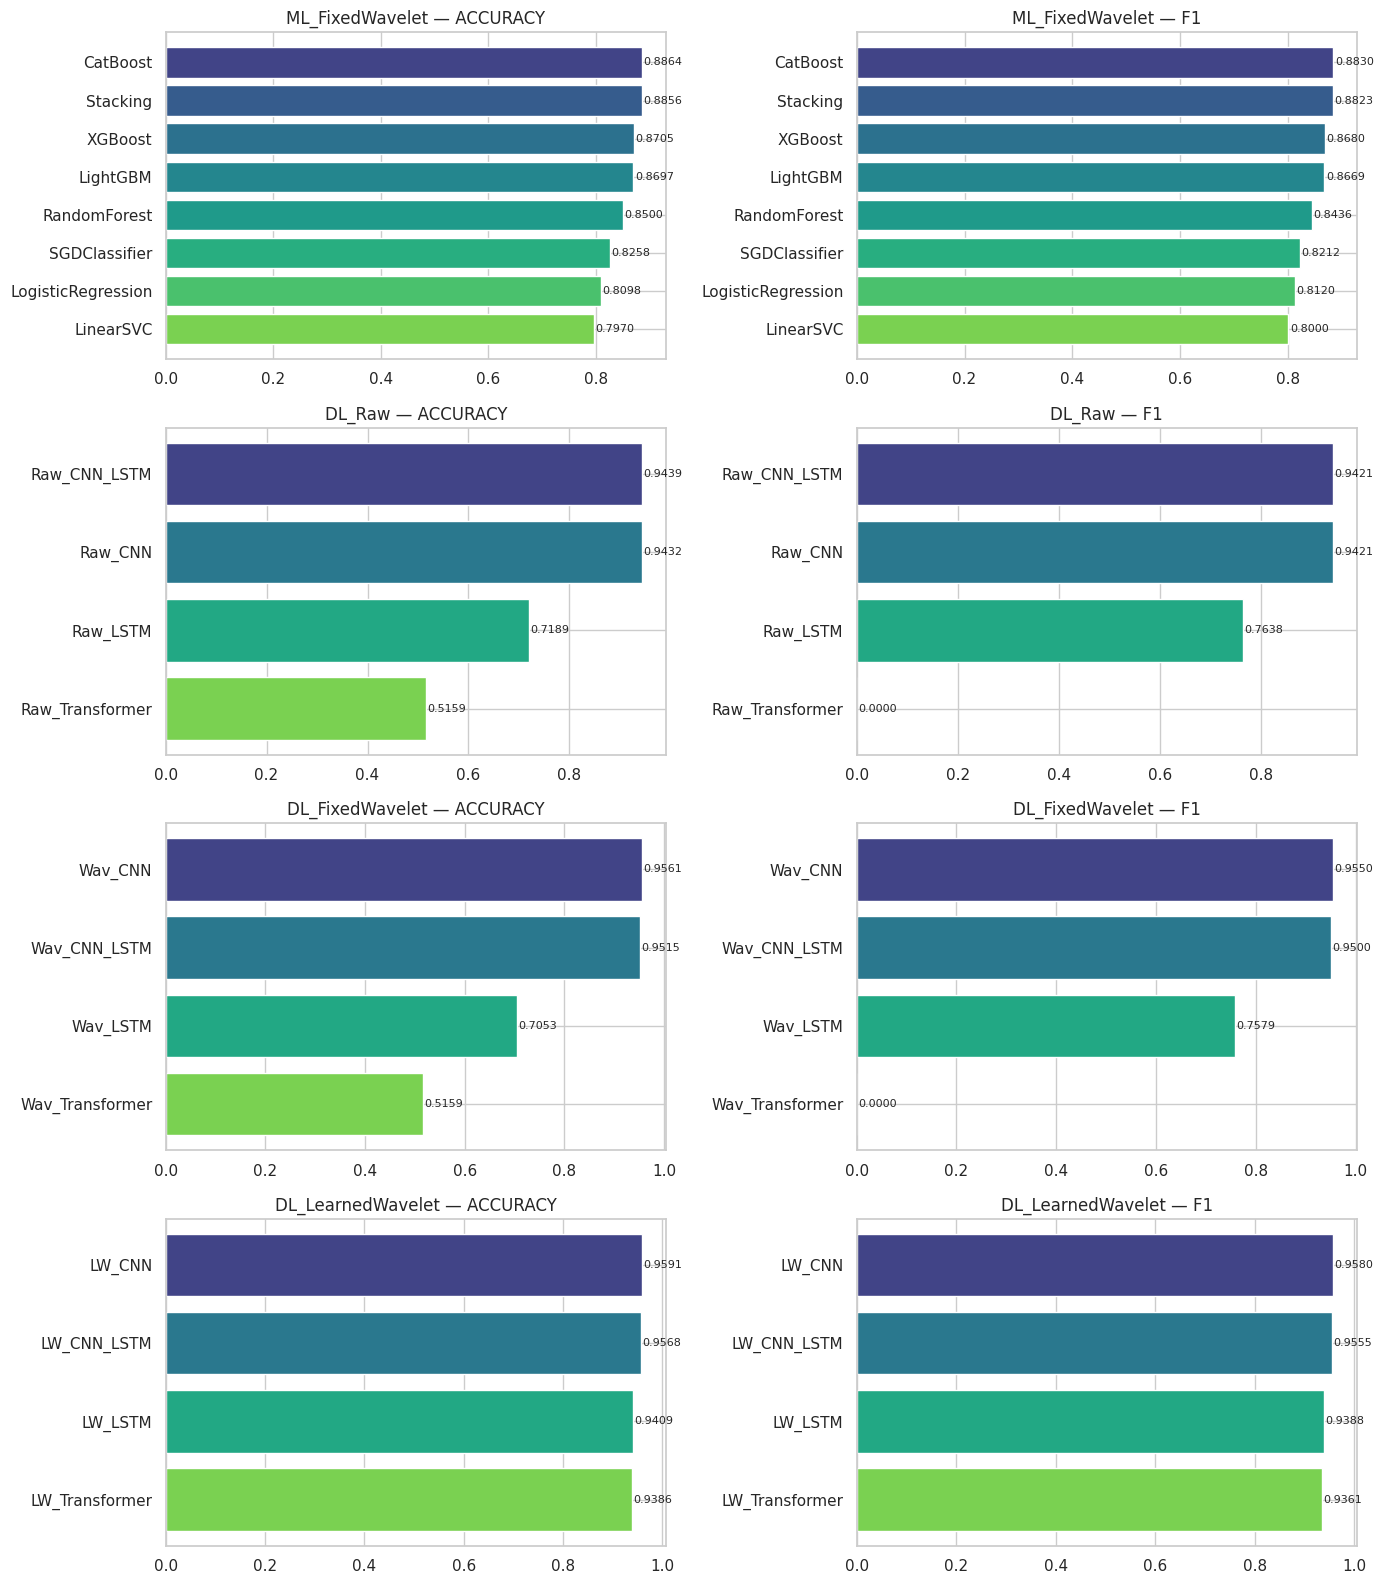

In [6]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"
    f1_col = "f1" if "f1" in results_df.columns else "F1"
    model_col = "Model" if "Model" in results_df.columns else results_df.columns[0]

    metrics_to_plot = []
    for c in [acc_col, f1_col]:
        if c in results_df.columns:
            metrics_to_plot.append(c)

    if metrics_to_plot:
        n_cats = results_df["Category"].nunique()
        fig, axes = plt.subplots(n_cats, len(metrics_to_plot),
                                 figsize=(7 * len(metrics_to_plot), 4 * n_cats))
        if n_cats == 1:
            axes = axes.reshape(1, -1)
        if len(metrics_to_plot) == 1:
            axes = axes.reshape(-1, 1)

        for i, cat in enumerate(results_df["Category"].unique()):
            cat_df = results_df[results_df["Category"] == cat].sort_values(acc_col, ascending=False)
            for j, metric in enumerate(metrics_to_plot):
                if metric in cat_df.columns:
                    values = cat_df[metric].values
                    names = cat_df[model_col].values
                    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
                    axes[i, j].barh(range(len(names)), values, color=colors)
                    axes[i, j].set_yticks(range(len(names)))
                    axes[i, j].set_yticklabels(names)
                    axes[i, j].set_title(f"{cat} — {metric.upper()}")
                    axes[i, j].invert_yaxis()
                    for bar, val in zip(axes[i, j].patches, values):
                        axes[i, j].text(bar.get_width() + 0.003,
                                        bar.get_y() + bar.get_height() / 2,
                                        f"{val:.4f}", va="center", fontsize=8)

        plt.tight_layout()
        plt.savefig(COMPARISON_DIR / "comparison_by_category.png", dpi=150, bbox_inches="tight")
        plt.show()

## 5. Ranking Global


RANKING GLOBAL — Todos os Modelos
                   Model           Category  accuracy        f1   auc_roc
Rank                                                                     
1                 LW_CNN  DL_LearnedWavelet  0.959091  0.958009  0.992228
2            LW_CNN_LSTM  DL_LearnedWavelet  0.956818  0.955504  0.990325
3                Wav_CNN    DL_FixedWavelet  0.956061  0.955039  0.988986
4           Wav_CNN_LSTM    DL_FixedWavelet  0.951515  0.950000  0.987616
5           Raw_CNN_LSTM             DL_Raw  0.943939  0.942097  0.984307
6                Raw_CNN             DL_Raw  0.943182  0.942085  0.984054
7                LW_LSTM  DL_LearnedWavelet  0.940909  0.938776  0.986175
8         LW_Transformer  DL_LearnedWavelet  0.938636  0.936069  0.981800
9               CatBoost    ML_FixedWavelet  0.886364  0.882995  0.961432
10              Stacking    ML_FixedWavelet  0.885606  0.882307  0.961288
11               XGBoost    ML_FixedWavelet  0.870455  0.867954  0.955336
12 

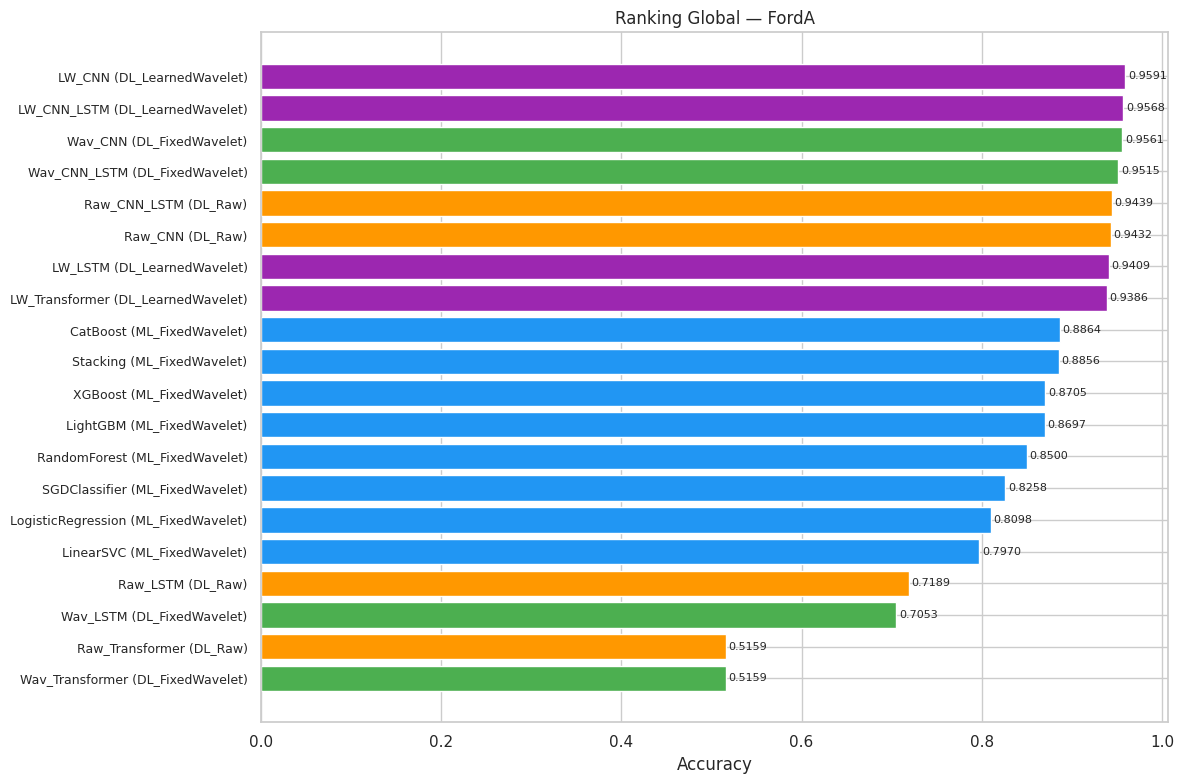

In [7]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"
    model_col = "Model" if "Model" in results_df.columns else results_df.columns[0]

    ranking = results_df.sort_values(acc_col, ascending=False).reset_index(drop=True)
    ranking.index = ranking.index + 1  # Ranking 1-based
    ranking.index.name = "Rank"

    print("\n" + "=" * 80)
    print("RANKING GLOBAL — Todos os Modelos")
    print("=" * 80)

    cols = [model_col, "Category"]
    for c in [acc_col, "f1", "F1", "auc_roc", "AUC_ROC"]:
        if c in ranking.columns:
            cols.append(c)
    cols = list(dict.fromkeys(cols))
    available = [c for c in cols if c in ranking.columns]
    print(ranking[available].to_string())

    # Salvar ranking
    ranking.to_csv(COMPARISON_DIR / "global_ranking.csv")

    # Visualização
    fig, ax = plt.subplots(figsize=(12, max(6, len(ranking) * 0.4)))
    colors = [{"ML_FixedWavelet": "#2196F3", "DL_Raw": "#FF9800",
               "DL_FixedWavelet": "#4CAF50", "DL_LearnedWavelet": "#9C27B0"}
              .get(c, "#757575") for c in ranking["Category"]]
    ax.barh(range(len(ranking)), ranking[acc_col].values, color=colors)
    ax.set_yticks(range(len(ranking)))
    ax.set_yticklabels([f"{r[model_col]} ({r['Category']})" for _, r in ranking.iterrows()], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Accuracy")
    ax.set_title("Ranking Global — FordA")
    for i, (_, r) in enumerate(ranking.iterrows()):
        ax.text(r[acc_col] + 0.003, i, f"{r[acc_col]:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / "global_ranking.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Análise Estatística das Categorias


ESTATÍSTICAS POR CATEGORIA:
------------------------------------------------------------
                       mean       std       min       max  count
Category                                                        
DL_LearnedWavelet  0.948864  0.010579  0.938636  0.959091      4
ML_FixedWavelet    0.849337  0.034651  0.796970  0.886364      8
DL_FixedWavelet    0.782197  0.212696  0.515909  0.956061      4
DL_Raw             0.780492  0.205731  0.515909  0.943939      4


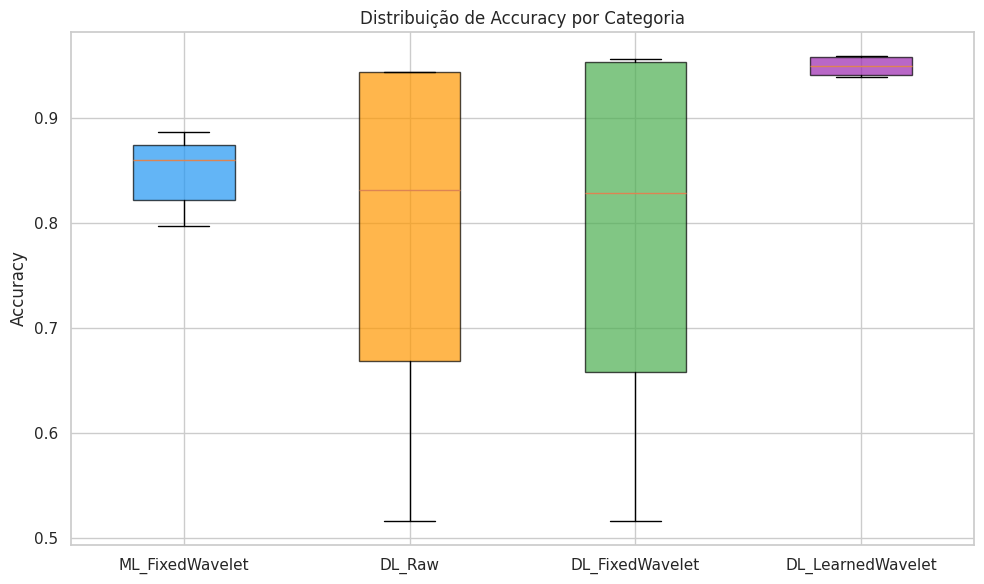

In [8]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"

    print("\nESTATÍSTICAS POR CATEGORIA:")
    print("-" * 60)
    stats = results_df.groupby("Category")[acc_col].agg(["mean", "std", "min", "max", "count"])
    stats = stats.sort_values("mean", ascending=False)
    print(stats.to_string())

    # Box plot
    fig, ax = plt.subplots(figsize=(10, 6))
    categories = results_df["Category"].unique()
    data_to_plot = [results_df[results_df["Category"] == c][acc_col].values for c in categories]
    bp = ax.boxplot(data_to_plot, labels=categories, patch_artist=True)
    colors_box = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
    for patch, color in zip(bp["boxes"], colors_box[:len(categories)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel("Accuracy")
    ax.set_title("Distribuição de Accuracy por Categoria")
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / "accuracy_by_category_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Comparação: Fixed Wavelet vs Learned Wavelet


FIXED WAVELET vs LEARNED WAVELET
  CNN: Fixed=0.9561  Learned=0.9591  Diff=+0.0030 (Learned)
  CNN_LSTM: Fixed=0.9515  Learned=0.9568  Diff=+0.0053 (Learned)
  LSTM: Fixed=0.7053  Learned=0.9409  Diff=+0.2356 (Learned)
  Transformer: Fixed=0.5159  Learned=0.9386  Diff=+0.4227 (Learned)


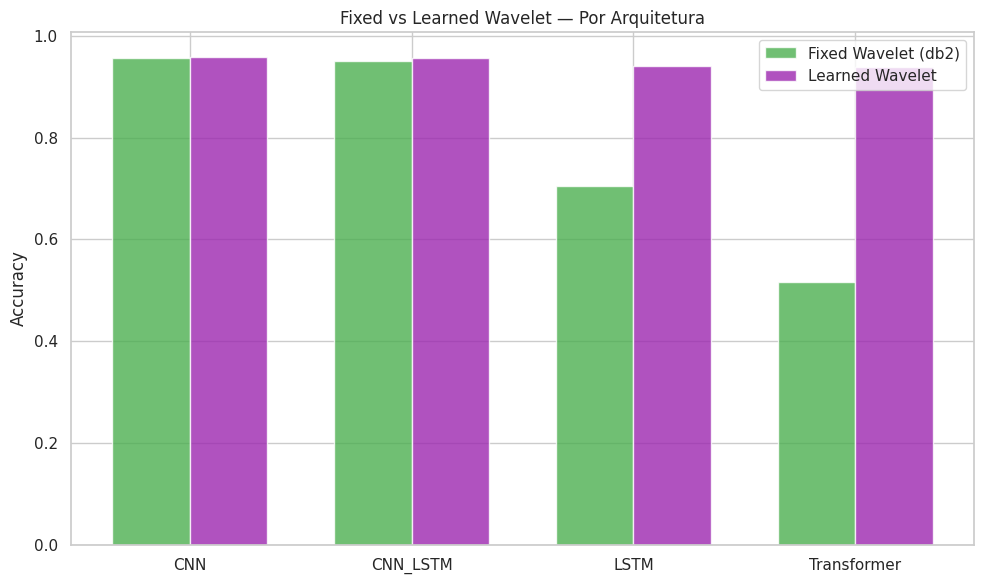

In [9]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"
    model_col = "Model" if "Model" in results_df.columns else results_df.columns[0]

    fixed_df = results_df[results_df["Category"] == "DL_FixedWavelet"].copy()
    learned_df = results_df[results_df["Category"] == "DL_LearnedWavelet"].copy()

    if len(fixed_df) > 0 and len(learned_df) > 0:
        print("\n" + "=" * 80)
        print("FIXED WAVELET vs LEARNED WAVELET")
        print("=" * 80)

        # Extrair arquitetura base para emparelhamento
        fixed_df["arch"] = fixed_df[model_col].str.replace("Wav_", "").str.replace("Fixed_", "")
        learned_df["arch"] = learned_df[model_col].str.replace("LW_", "").str.replace("Learned_", "")

        for arch in fixed_df["arch"].unique():
            f = fixed_df[fixed_df["arch"] == arch]
            l = learned_df[learned_df["arch"] == arch]
            if len(f) > 0 and len(l) > 0:
                f_acc = f[acc_col].max()
                l_acc = l[acc_col].max()
                diff = l_acc - f_acc
                winner = "Learned" if diff > 0 else "Fixed"
                print(f"  {arch}: Fixed={f_acc:.4f}  Learned={l_acc:.4f}  Diff={diff:+.4f} ({winner})")

        # Bar chart comparativo
        archs = sorted(set(fixed_df["arch"].tolist()) & set(learned_df["arch"].tolist()))
        if archs:
            fig, ax = plt.subplots(figsize=(10, 6))
            x = np.arange(len(archs))
            w = 0.35
            fixed_vals = [fixed_df[fixed_df["arch"] == a][acc_col].max() for a in archs]
            learned_vals = [learned_df[learned_df["arch"] == a][acc_col].max() for a in archs]
            ax.bar(x - w/2, fixed_vals, w, label="Fixed Wavelet (db2)", color="#4CAF50", alpha=0.8)
            ax.bar(x + w/2, learned_vals, w, label="Learned Wavelet", color="#9C27B0", alpha=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(archs)
            ax.set_ylabel("Accuracy")
            ax.set_title("Fixed vs Learned Wavelet — Por Arquitetura")
            ax.legend()
            plt.tight_layout()
            plt.savefig(COMPARISON_DIR / "fixed_vs_learned.png", dpi=150, bbox_inches="tight")
            plt.show()
    else:
        print("Dados insuficientes para comparação Fixed vs Learned.")

## 8. Análise: Raw vs Wavelet Preprocessing


RAW vs WAVELET PREPROCESSING


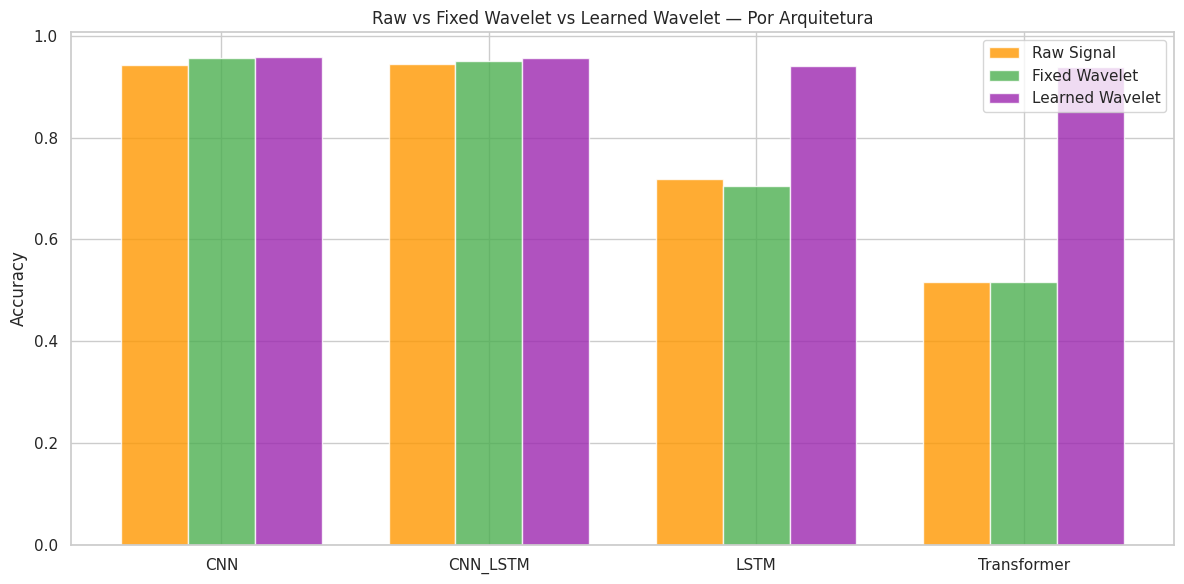

In [10]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"
    model_col = "Model" if "Model" in results_df.columns else results_df.columns[0]

    raw_df = results_df[results_df["Category"] == "DL_Raw"].copy()
    wav_df = results_df[results_df["Category"] == "DL_FixedWavelet"].copy()
    lw_df = results_df[results_df["Category"] == "DL_LearnedWavelet"].copy()

    if len(raw_df) > 0 and (len(wav_df) > 0 or len(lw_df) > 0):
        print("\n" + "=" * 80)
        print("RAW vs WAVELET PREPROCESSING")
        print("=" * 80)

        raw_df["arch"] = raw_df[model_col].str.replace("Raw_", "")
        wav_df["arch"] = wav_df[model_col].str.replace("Wav_", "") if len(wav_df) > 0 else pd.Series()
        lw_df["arch"] = lw_df[model_col].str.replace("LW_", "") if len(lw_df) > 0 else pd.Series()

        archs = sorted(raw_df["arch"].unique())
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(archs))
        w = 0.25

        raw_vals = [raw_df[raw_df["arch"] == a][acc_col].max() if a in raw_df["arch"].values else 0 for a in archs]
        ax.bar(x - w, raw_vals, w, label="Raw Signal", color="#FF9800", alpha=0.8)

        if len(wav_df) > 0:
            wav_vals = [wav_df[wav_df["arch"] == a][acc_col].max() if a in wav_df["arch"].values else 0 for a in archs]
            ax.bar(x, wav_vals, w, label="Fixed Wavelet", color="#4CAF50", alpha=0.8)

        if len(lw_df) > 0:
            lw_vals = [lw_df[lw_df["arch"] == a][acc_col].max() if a in lw_df["arch"].values else 0 for a in archs]
            ax.bar(x + w, lw_vals, w, label="Learned Wavelet", color="#9C27B0", alpha=0.8)

        ax.set_xticks(x)
        ax.set_xticklabels(archs)
        ax.set_ylabel("Accuracy")
        ax.set_title("Raw vs Fixed Wavelet vs Learned Wavelet — Por Arquitetura")
        ax.legend()
        plt.tight_layout()
        plt.savefig(COMPARISON_DIR / "raw_vs_wavelet.png", dpi=150, bbox_inches="tight")
        plt.show()

## 9. Relatório Final

In [11]:
if len(results_df) > 0:
    acc_col = "accuracy" if "accuracy" in results_df.columns else "Accuracy"
    model_col = "Model" if "Model" in results_df.columns else results_df.columns[0]

    ranking = results_df.sort_values(acc_col, ascending=False)
    best = ranking.iloc[0]

    print("\n" + "=" * 80)
    print("RELATÓRIO FINAL — FordA Classification")
    print("=" * 80)

    print(f"\n1. Dataset: FordA (UCR Time Series Classification)")
    print(f"   Tarefa: Classificação binária")
    print(f"   Comprimento do sinal: 500 pontos")

    print(f"\n2. Total de modelos avaliados: {len(results_df)}")
    for cat in results_df["Category"].unique():
        n = len(results_df[results_df["Category"] == cat])
        print(f"   - {cat}: {n} modelos")

    print(f"\n3. Melhor modelo geral:")
    print(f"   {best[model_col]} ({best['Category']})")
    for c in [acc_col, "f1", "F1", "auc_roc", "AUC_ROC"]:
        if c in best.index and pd.notna(best[c]):
            print(f"   {c}: {best[c]:.4f}")

    print(f"\n4. Top 5 modelos:")
    for i, (_, row) in enumerate(ranking.head(5).iterrows()):
        print(f"   {i+1}. {row[model_col]} ({row['Category']}) — Acc={row[acc_col]:.4f}")

    # Salvar relatório
    ranking.to_csv(COMPARISON_DIR / "final_report.csv", index=False)
    print(f"\nRelatório salvo em {COMPARISON_DIR}")


RELATÓRIO FINAL — FordA Classification

1. Dataset: FordA (UCR Time Series Classification)
   Tarefa: Classificação binária
   Comprimento do sinal: 500 pontos

2. Total de modelos avaliados: 20
   - ML_FixedWavelet: 8 modelos
   - DL_Raw: 4 modelos
   - DL_FixedWavelet: 4 modelos
   - DL_LearnedWavelet: 4 modelos

3. Melhor modelo geral:
   LW_CNN (DL_LearnedWavelet)
   accuracy: 0.9591
   f1: 0.9580
   auc_roc: 0.9922

4. Top 5 modelos:
   1. LW_CNN (DL_LearnedWavelet) — Acc=0.9591
   2. LW_CNN_LSTM (DL_LearnedWavelet) — Acc=0.9568
   3. Wav_CNN (DL_FixedWavelet) — Acc=0.9561
   4. Wav_CNN_LSTM (DL_FixedWavelet) — Acc=0.9515
   5. Raw_CNN_LSTM (DL_Raw) — Acc=0.9439

Relatório salvo em /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/comparison_analysis


## 10. Conclusão

In [12]:
print("\n" + "=" * 80)
print("ANÁLISE COMPARATIVA CONCLUÍDA!")
print("=" * 80)
print(f"\nTodos os resultados consolidados em: {COMPARISON_DIR}")
print("\nArquivos gerados:")
for f in sorted(COMPARISON_DIR.glob("*")):
    print(f"  {f.name}")


ANÁLISE COMPARATIVA CONCLUÍDA!

Todos os resultados consolidados em: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/results/comparison_analysis

Arquivos gerados:
  accuracy_by_category_boxplot.png
  comparison_by_category.png
  final_report.csv
  fixed_vs_learned.png
  global_ranking.csv
  global_ranking.png
  raw_vs_wavelet.png
